# Classical Data Science Pipeline with scikit-learn

## Introduction

This notebook walks through a complete data science pipeline (or workflow) using traditional machine learning approaches with scikit-learn. Understanding this workflow is essential before diving into deep learning, as deep learning models will eventually replace the traditional ML models in this same workflow. Therefore, understanding this workflow provides the foundation for how deep learning fits into the data science workflow and how it differs from traditional Machine Learning and inform how we should use it and where we need to pay attention.

Big picture view:
- **Data Science** aims to extract insights and gain knowledge from data (hence it is called *science*). This includes the following steps (not exhaustive):
    1. Data collection
    2. Cleaning
    3. Exploration
    4. Visualization
    5. Statistical analysis
    6. Data modeling and *machine learning*
    7. Communication of results/insights
- **Machine Learning** (ML) aims to learn patterns from the data to make predictions about new data. Key concepts for machine learning tasks:
    - Feature engineering (often manual and requiring domain expertise)
    - Model selection
    - Validation
    - Hyperparameter tuning
- **Deep Learning** (DL) is a specialized subset of ML based on artificial neural networks. DL aims to learn features from the data itself rather than performing feature engineering.

We'll walk through these key steps:
1. Data Loading and Exploratory Data Analysis
2. Train/Validation/Test Split
3. Data Preprocessing
4. Model Training (scikit-learn)
5. Model Validation and Comparison
6. Feature Importance Analysis
8. Inference Pipeline
7. Visualization

## Essential pandas and scikit-learn Basics

### pandas
**pandas** is a Python library for data manipulation and analysis that provides two key data structures:

- **pd.DataFrame**: A two-dimensional table with labeled rows and columns, similar to a spreadsheet. This is the primary structure used for working with datasets in pandas.
- **pd.Series**: A one-dimensional labeled array, equivalent to a single column in a DataFrame.

In this notebook, we use pandas primarily for its ease of use and simplicity in handling the data. Specifically this includes:

- **Exploring data**: 
  - `df.head()`: Shows the first few rows of a DataFrame, giving you a quick preview of your data
  - `df.shape`: Returns a tuple representing the dimensions of your DataFrame (rows, columns)
- **Selecting and manipulating data**: 
  - Access columns with `df['column_name']` or select subsets with `df.loc[]` 
  - Compute statistics with `df.describe()`, `df.mean()`, or `df.corr()`
- **Preparing data for machine learning**:
  - Handle missing values with `df.fillna()` or `df.dropna()`
  - Transform features as needed before training models

### scikit-learn
**scikit-learn** (imported as sklearn) provides tools for machine learning with a consistent, user-friendly interface. 

Key components used in this notebook:

**Data Splitting**: 
- `train_test_split`: Divides your data into training and testing sets, allowing you to build models on one subset and evaluate them on another

**Data Preprocessing**:
- `StandardScaler`: Standardizes features by removing the mean and scaling to unit variance
- The preprocessing workflow follows a pattern:
  - `fit`: Learns parameters from training data (like mean and standard deviation)
  - `transform`: Applies those parameters to transform data
  - `fit_transform`: Combines both steps for convenience on training data (but only use `transform` on test data)

**Model Training and Prediction**:
- All sklearn models share a consistent API:
  - Initialize a model (e.g., `LogisticRegression()`, `RandomForestClassifier()`)
  - `model.fit(X_train, y_train)`: Trains the model on your data
  - `model.predict(X_test)`: Generates predictions for new data

**Evaluation Metrics**:
- `accuracy_score`: Percentage of correctly classified samples
- `roc_auc_score`: Area under the ROC curve, measuring discrimination ability
- `classification_report`: Detailed metrics including precision, recall, and F1-score
- `confusion_matrix`: Table showing true positives, false positives, true negatives, and false negatives

**Feature Analysis**:
- `model.feature_importances_`: Available for tree-based models, shows how much each feature contributes to predictions
- `model.coef_`: Available for linear models (like LogisticRegression), provides the coefficients/weights assigned to each feature

This workflow -- prepare data, train models, make predictions, and evaluate results -- forms the backbone of the machine learning process demonstrated in this notebook.

## Setup and Imports
Let's begin by installing and importing the necessary libraries.

In [ ]:
# we first install all required packages into our conda environment, if needed
!conda install -yy numpy matplotlib pandas seaborn
!pip install scikit-learn

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# sklearn components (need to be imported explicitly)
import sklearn.model_selection
import sklearn.datasets
import sklearn.preprocessing
import sklearn.linear_model
import sklearn.ensemble
import sklearn.metrics

# For reproducibility
np.random.seed(42)

# Plotting settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)


## Step 1: Data Loading

In this step, we'll load a dataset for binary classification. We'll use the Breast Cancer Wisconsin dataset, which is included in scikit-learn's sample datasets.

In [3]:
# Load the breast cancer wisconsin dataset
data = sklearn.datasets.load_breast_cancer()

# Only use the first N (1 <= N <= 30) features to make it easier to visualize and make the problem harder
n_features = 3

X = pd.DataFrame(data.data[:,:n_features], columns=data.feature_names[:n_features])
t = pd.Series(data.target)

# Display dataset information
print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(t))}")
print(f"Class distribution: \n{t.value_counts()}")

Dataset shape: (569, 3)
Number of classes: 2
Class distribution: 
1    357
0    212
Name: count, dtype: int64


In [4]:
# Display the first few rows of the dataset
X.head()

,mean radius,mean texture,mean perimeter
0,17.99,10.38,122.80
1,20.57,17.77,132.90
2,19.69,21.25,130.00
3,11.42,20.38,77.58
4,20.29,14.34,135.10


In [5]:
# Basic exploratory data analysis
X.describe()

,mean radius,mean texture,mean perimeter
count,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033
std,3.524049,4.301036,24.298981
min,6.981000,9.710000,43.790000
25%,11.700000,16.170000,75.170000
50%,13.370000,18.840000,86.240000
75%,15.780000,21.800000,104.100000
max,28.110000,39.280000,188.500000


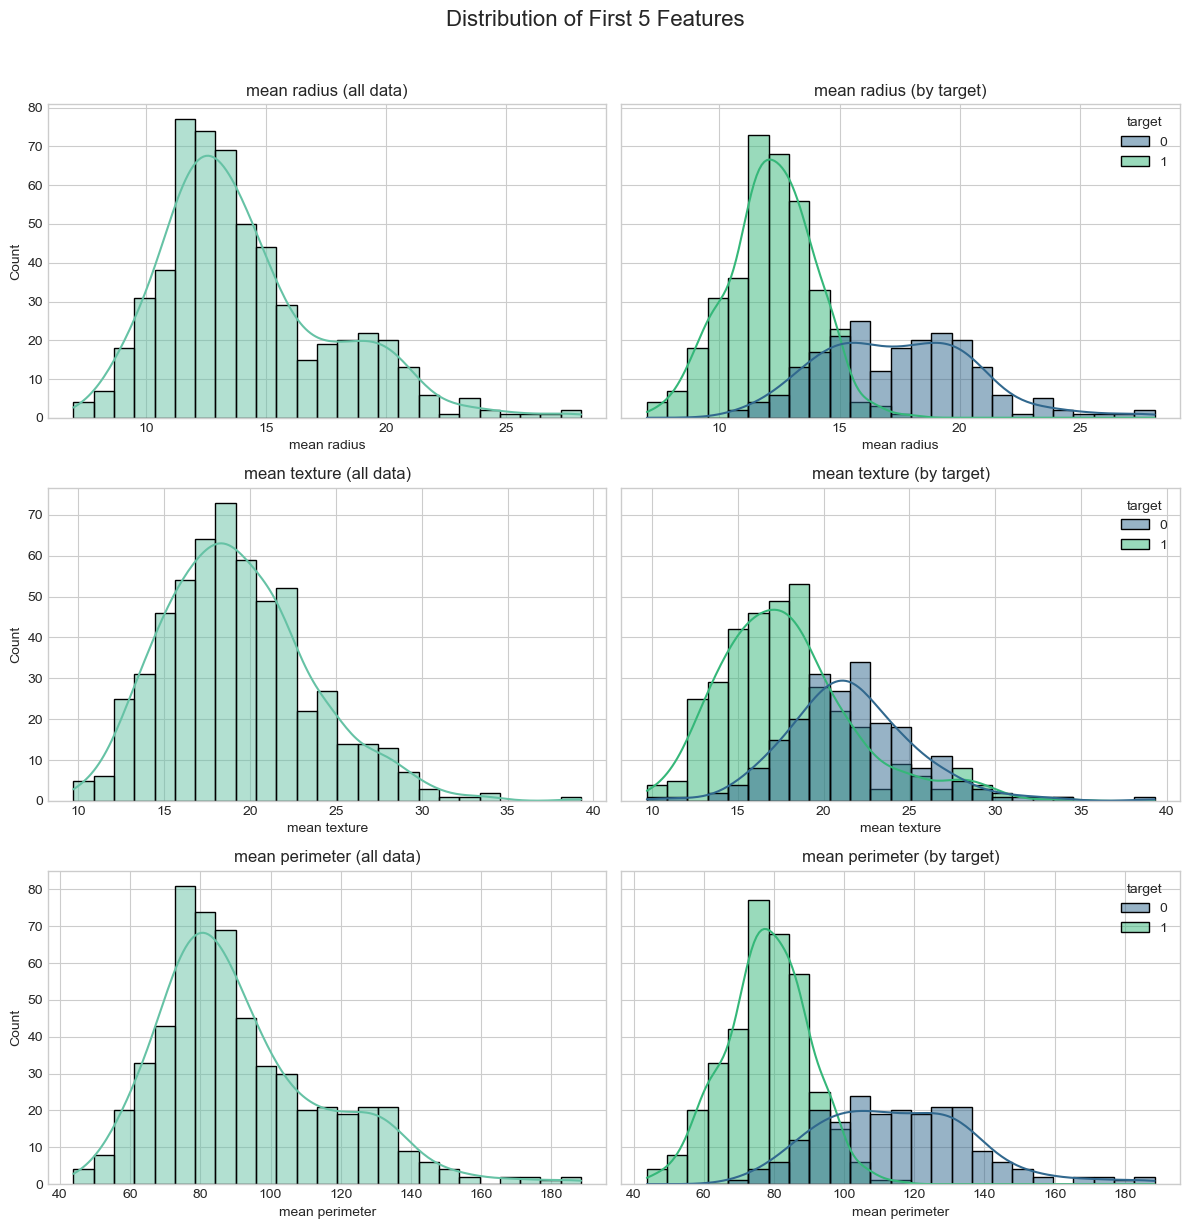

In [6]:
# Let's visualize some features

# Combine the features and target into a single DataFrame for visualization only
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = t

# Plot histograms for the first 5 features
first_n_features = min(5, n_features)
fig, axs = plt.subplots(first_n_features, 2, figsize=(12, 4*first_n_features), sharey='row')

for i, feature in enumerate(X.columns[:first_n_features]):

    ax = axs[i, 0]
    sns.histplot(X[feature], kde=True, bins=25, ax=ax)
    ax.set_title(f'{feature} (all data)')

    ax = axs[i, 1]
    sns.histplot(data=df, x=feature, hue='target', kde=True, bins=25, palette='viridis', ax=ax)
    ax.set_title(f'{feature} (by target)')

    fig.tight_layout()

plt.suptitle('Distribution of First 5 Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


## Step 2: Train/Validation/Test Split

In this step, we'll split our data into three parts:
1. Training set (60%): Used to train the models
2. Validation set (20%): Used to tune hyperparameters and compare models (on data they have not seen during training)

       Important: Never perform hyperparameter optimization on the test set. This would render any conclusion about model performance meaningless since the model could be overfitting very hard and perform poorly on unseen data (real applications) and we would have no way of knowing it.

3. Test set (20%): Used only for final evaluation of the best model to know how well they perform on data they have not seen during training or hyperparameter optimization

       Important: This separation is crucial to avoid data leakage and ensure honest evaluation.

In [7]:
# First split: 80% train+val, 20% test
X_train_val, X_test, t_train_val, t_test = sklearn.model_selection.train_test_split(
    X, t, test_size=0.2, random_state=42, stratify=t
)

# Second split: 75% train, 25% val (resulting in 60%/20%/20% overall)
X_train, X_val, t_train, t_val = sklearn.model_selection.train_test_split(
    X_train_val, t_train_val, test_size=0.25, random_state=42, stratify=t_train_val
)

# Display the shapes of the resulting datasets
print(f"Training set: {X_train.shape}, {t_train.shape}")
print(f"Validation set: {X_val.shape}, {t_val.shape}")
print(f"Test set: {X_test.shape}, {t_test.shape}")


Training set: (341, 3), (341,)
Validation set: (114, 3), (114,)
Test set: (114, 3), (114,)


## Step 3: Feature Preprocessing

Before training our models, let's standardize our features to have zero mean and unit variance. This helps many ML algorithms perform better and is often also required for deep learning tasks, e.g. normalization of pixel values.

    Important: Fit the scaler **only on the training data**, never on the validation or test data.

In [8]:
# Initialize the scaler
scaler = sklearn.preprocessing.StandardScaler()

# Fit the scaler on the training data and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to pandas DataFrames for easier manipulation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Display the first few rows of the scaled training data
X_train_scaled.head()

,mean radius,mean texture,mean perimeter
0,-1.228111,-1.336440,-1.113713
1,0.061953,0.560834,0.090635
2,-0.420341,-0.633255,-0.414612
3,0.219897,-0.991481,0.132671
4,-0.832123,-0.078225,-0.739063


## Step 4: Train Models

Now that our data is prepared, we'll train two different classification models:
1. Logistic Regression (LR)
2. Support Vector Machine (SVM)
3. Random Forest Classifier (RF)

In [9]:
# Model 1: Logistic Regression
lr_model = sklearn.linear_model.LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, t_train)

# Model 2: Support Vector Machine
svm_model = sklearn.svm.SVC(kernel='linear', random_state=42, probability=True)
svm_model.fit(X_train_scaled, t_train)

# Model 3: Random Forest
rf_model = sklearn.ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, t_train)

models = {
    "Logistic Regression": lr_model,
    "Support Vector Machine": svm_model,
    "Random Forest": rf_model
}

print("Models trained successfully!")

Models trained successfully!


## Step 5: Model Validation and Comparison

Let's evaluate our models on the validation set to compare their performance.

Evaluating LogisticRegression on the Validation set

Performance on Validation set:
Accuracy: 0.9123
ROC AUC: 0.9807

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        43
           1       0.93      0.93      0.93        71

    accuracy                           0.91       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



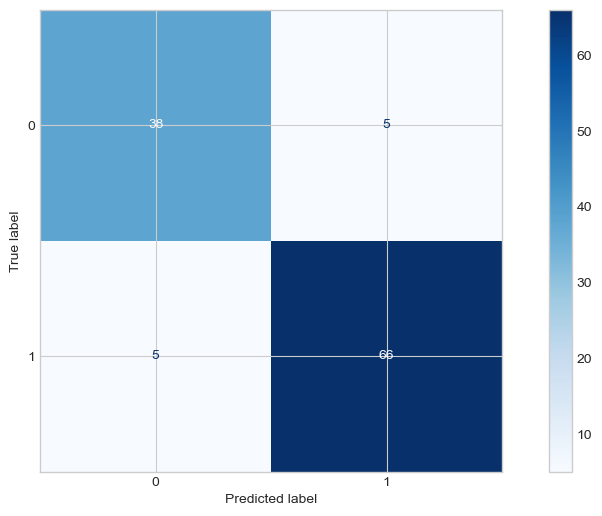

Evaluating SVC on the Validation set

Performance on Validation set:
Accuracy: 0.9123
ROC AUC: 0.9790

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        43
           1       0.93      0.93      0.93        71

    accuracy                           0.91       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



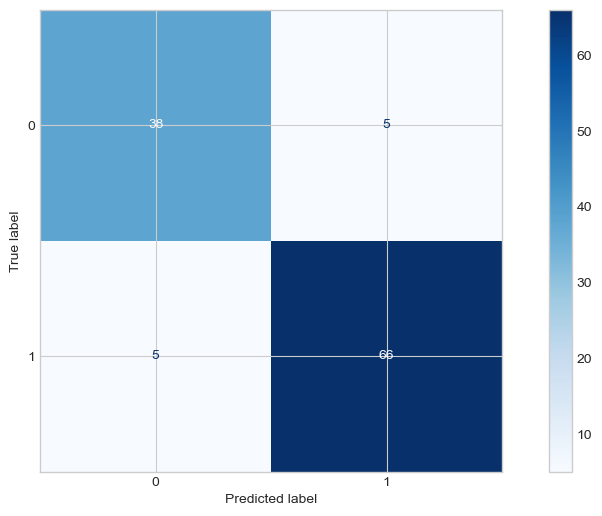

Evaluating RandomForestClassifier on the Validation set

Performance on Validation set:
Accuracy: 0.8947
ROC AUC: 0.9690

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        43
           1       0.90      0.93      0.92        71

    accuracy                           0.89       114
   macro avg       0.89      0.88      0.89       114
weighted avg       0.89      0.89      0.89       114



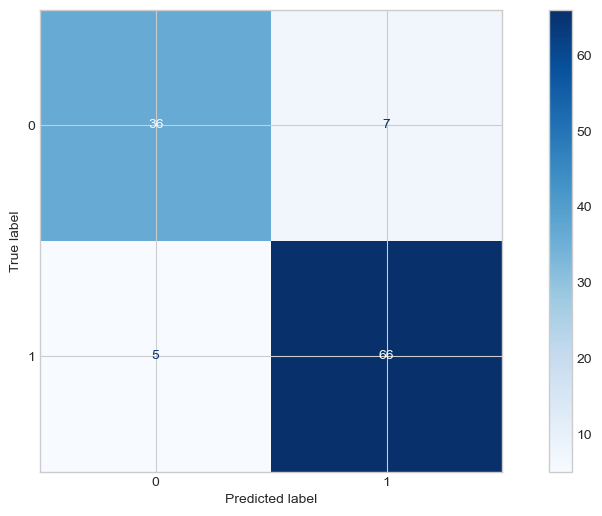

In [10]:
# Create a function to evaluate and display model performance
def evaluate_model(model, X, t, dataset_split):
    title = f"Evaluating {model.__class__.__name__} on the {dataset_split} set"
    print(f"{title}\n{'='*len(title)}\n")

    # Make predictions
    y_pred = model.predict(X)
    y = model.predict_proba(X)[:, 1]

    # Calculate metrics
    accuracy = sklearn.metrics.accuracy_score(t, y_pred)
    auc = sklearn.metrics.roc_auc_score(t, y)

    # Print results
    print(f"Performance on {dataset_split} set:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(sklearn.metrics.classification_report(t, y_pred))

    # Create confusion matrix
    sklearn.metrics.ConfusionMatrixDisplay.from_predictions(t, y_pred, normalize=None, cmap='Blues')
    plt.show()

    # Return metrics for comparison
    return {
        'accuracy': accuracy,
        'auc': auc,
        'y': y
    }

# compute metrics for all of our models
metrics = {}
for name, model in models.items():
    metrics[name] = evaluate_model(model, X_val_scaled, t_val, "Validation")

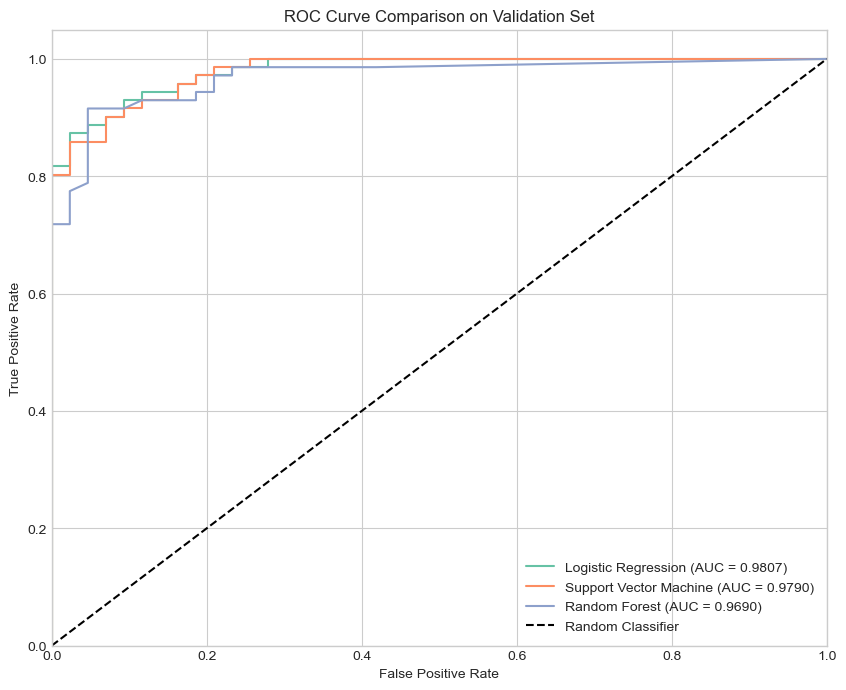

In [11]:
# Compare ROC curves for both models
plt.figure(figsize=(10, 8))

for model, metric in metrics.items():
    fpr, tpr, _ = sklearn.metrics.roc_curve(t_val, metric['y'])
    auc = sklearn.metrics.roc_auc_score(t_val, metric['y'])
    plt.plot(fpr, tpr, label=f"{model} (AUC = {auc:.4f})")

# Add diagonal line representing random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison on Validation Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

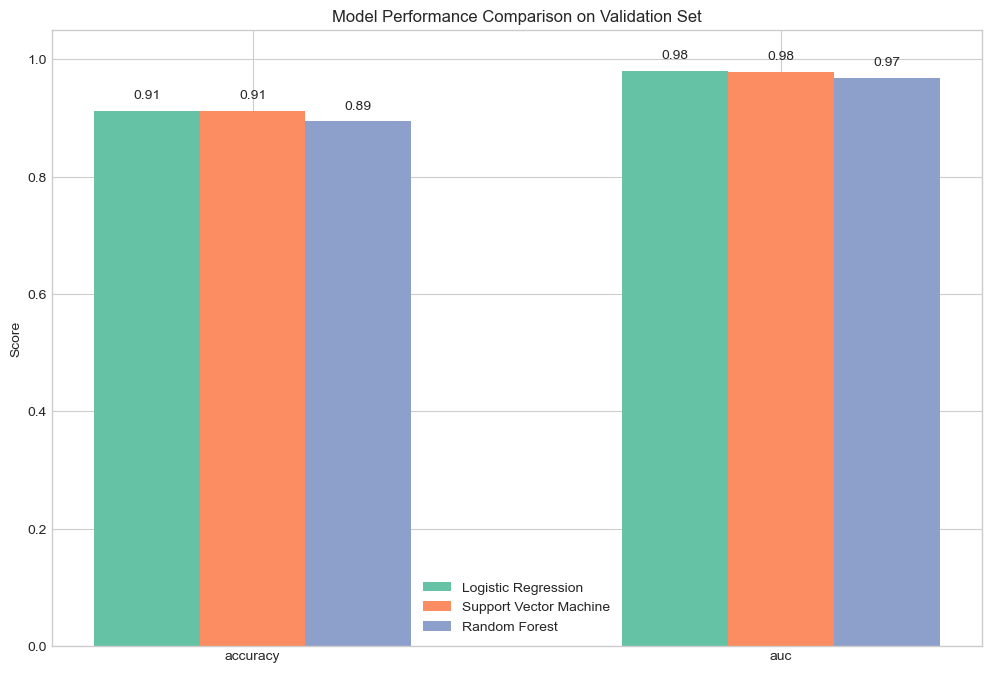

In [12]:
# Compare model performance metrics in a bar chart
metrics_to_compare = ['accuracy', 'auc']

# Prepare data for plotting
nr_models = len(models)
metric_values = np.zeros((nr_models, len(metrics_to_compare)))
for i, model_name in enumerate(models):
    for j, metric_name in enumerate(metrics_to_compare):
        metric_values[i, j] = metrics[model_name][metric_name]

# Create bar chart
plt.figure(figsize=(12, 8))
x = np.arange(len(metrics_to_compare))
width = 0.2

for i, model_name in enumerate(models):
    plt.bar(x + (i-1)*width, metric_values[i, :], width, label=model_name)

plt.ylabel('Score')
plt.title('Model Performance Comparison on Validation Set')
plt.xticks(x, metrics_to_compare)
plt.legend()
plt.ylim([0, 1.05])

# add the actual value on top of the bar
for i, model_name in enumerate(models):
    for j, metric_name in enumerate(metrics_to_compare):
        plt.text(x[j] + (i-1)*width, metric_values[i, j] + 0.02, f"{metric_values[i, j]:.2f}", ha='center')


## Step 6: Feature Importance Analysis

Understanding which features are most influential can provide valuable insights. Let's examine feature importance for both models.


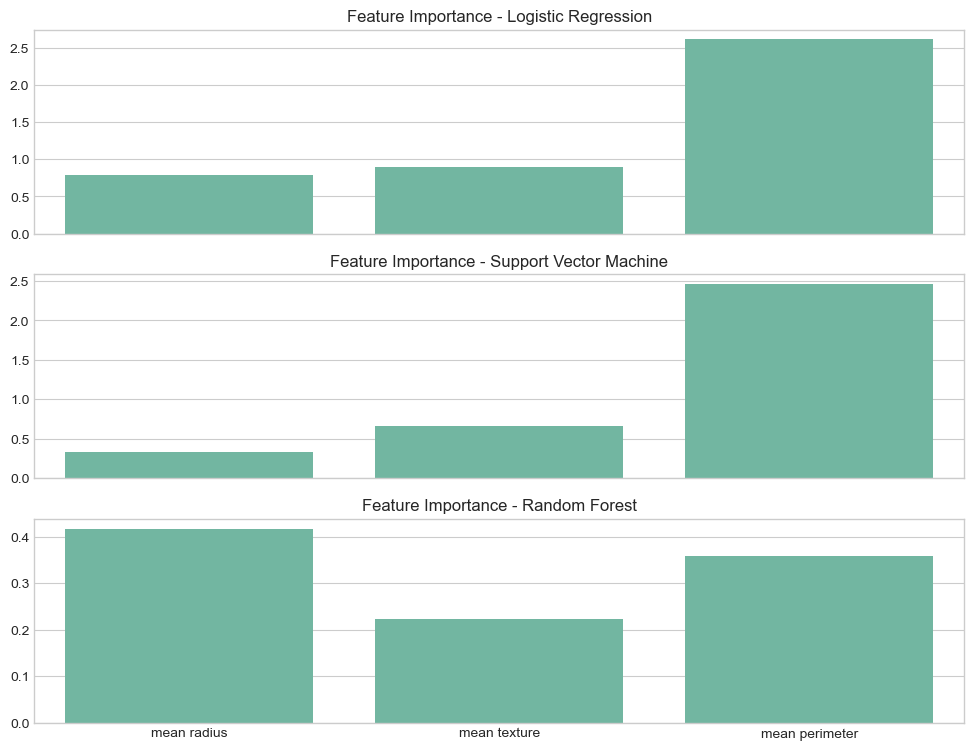

In [13]:
fig, axs = plt.subplots(len(models), 1, figsize=(12, 3*len(models)), sharex=True)

# Analyze the feature importance of the models
for i, (model_name, model) in enumerate(models.items()):

    # for logistic regression
    if hasattr(model, 'coef_'):
        importance = np.abs(model.coef_[0])

    # for random forest and SVM
    elif hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_

    else:
        continue

    sns.barplot(x=X.columns, y=importance, ax=axs[i])
    axs[i].set_title(f'Feature Importance - {model_name}')

plt.xlabel("")
plt.show()

## Step 7: Model Selection

Based on our validation results, let's select the best model.

In [14]:
# Compare model performance on validation set
# Select the best model based on AUC score
best_model_name = None
best_model = None
best_auc = 0

for model_name, model in models.items():
    auc = metrics[model_name]['auc']
    if auc > best_auc:
        best_auc = auc
        best_model_name = model_name
        best_model = model

print(f"Selected best model: {best_model_name}")
print(f"Validation AUC: {metrics[best_model_name]['auc']:.4f}")

Selected best model: Logistic Regression
Validation AUC: 0.9807


## Step 8: Hyperparameter Tuning



C=0.0001, AUC=0.9781
C=0.0008, AUC=0.9781
C=0.0060, AUC=0.9781
C=0.0464, AUC=0.9777
C=0.3594, AUC=0.9800
C=2.7826, AUC=0.9826
C=21.5443, AUC=0.9856
C=166.8101, AUC=0.9872
C=1291.5497, AUC=0.9872
C=10000.0000, AUC=0.9866
Best C: 166.8101
Best AUC score: 0.9872


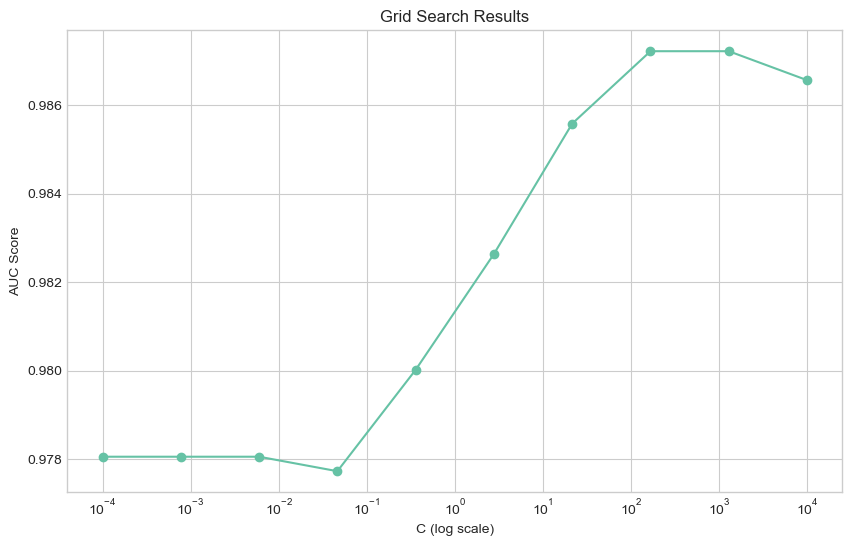

In [15]:
# We pick the logistic regression model and optimize the weight for the regularization term

# Define the hyperparameter grid to search
param_grid = np.logspace(-4, 4, 10)

auc_values = []
models_given_c = []

for C in param_grid:
    model = sklearn.linear_model.LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_train_scaled, t_train)
    y = model.predict_proba(X_val_scaled)[:, 1]
    auc = sklearn.metrics.roc_auc_score(t_val, y)
    print(f"C={C:.4f}, AUC={auc:.4f}")

    auc_values.append(auc)
    models_given_c.append(model)

# get the best c (where auc is the highest)
best_auc = max(auc_values)
best_c = param_grid[auc_values.index(best_auc)]

# Display the best hyperparameters
print(f"Best C: {best_c:.4f}")
print(f"Best AUC score: {best_auc:.4f}")

# Plot the grid search results
plt.figure(figsize=(10, 6))
plt.plot(param_grid, auc_values, marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('AUC Score')
plt.title('Grid Search Results')
plt.grid(True)
plt.show()

# We pick the best model
tuned_model = models_given_c[auc_values.index(best_auc)]

## Step 9: Testing
Now that we have our tuned model, let's evaluate it on the test set to find out how well it generalizes to unseen data.

Evaluating LogisticRegression on the Test set

Performance on Test set:
Accuracy: 0.9211
ROC AUC: 0.9762

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        42
           1       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



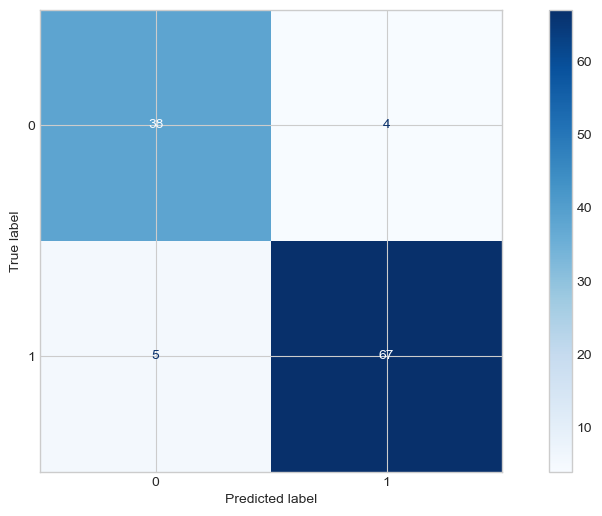


Performance comparison for Logistic Regression:
Validation AUC: 0.9807
Test AUC: 0.9762
Difference: -0.0045


In [16]:
# Evaluate the best model on the test set
test_metrics = evaluate_model(tuned_model, X_test_scaled, t_test, "Test")

# Compare validation vs test performance
print(f"\nPerformance comparison for {best_model_name}:")
print(f"Validation AUC: {metrics[best_model_name]['auc']:.4f}")
print(f"Test AUC: {test_metrics['auc']:.4f}")
print(f"Difference: {test_metrics['auc'] - metrics[best_model_name]['auc']:.4f}")

## Step 10: Inference Pipeline

Now let's create a complete inference (i.e. prediction) pipeline that could be used for making predictions on new data (e.g. once deployed in some application).

In [17]:
def inference_pipeline(new_data, model=best_model, scaler=scaler):
    """
    End-to-end inference pipeline for new data.

    Parameters:
    new_data (DataFrame): New feature data in the same format as the training data
    model: Trained model
    scaler: Fitted feature scaler

    Returns:
    Tuple: (predictions, prediction probabilities)
    """
    # Ensure the data has the right columns
    expected_columns = X.columns
    if not all(col in new_data.columns for col in expected_columns):
        raise ValueError("New data must have the same features as training data")

    # Apply preprocessing
    new_data_scaled = scaler.transform(new_data[expected_columns])

    # Make predictions
    predictions = model.predict(new_data_scaled)
    pred_probabilities = model.predict_proba(new_data_scaled)[:, 1]

    return predictions, pred_probabilities

In [ ]:
# Demonstrate the inference pipeline with sample data
# Because we don't have new data, we are re-using a few samples from the test set for demonstration purposes
sample_data = X_test.iloc[:5].copy()

# Make predictions
sample_predictions, sample_probabilities = inference_pipeline(sample_data)

# Display results
results = pd.DataFrame({
    'True Label': t_test.iloc[:5],
    'Predicted Label': sample_predictions,
    'Probability (Class 1)': sample_probabilities
})

display(results)

## Summary

In this notebook, we've walked through a complete traditional machine learning workflow:

### Deep Learning Integration

When integrating deep learning into this workflow later, you'll follow a similar process with a few key differences:

1. **Model Architecture**: Replace scikit-learn models with neural network architectures
2. **Training Process**: Use mini-batch training and manage epochs
3. **Framework**: Switch from scikit-learn to frameworks like PyTorch
4. **Computational Resources**: Leverage GPUs/TPUs for training
5. **Regularization Techniques**: Use dropout, batch normalization, etc.
6. **Evaluation**: Use the same metrics but implement custom training loops

The overall workflow structure remains the same - the deep learning model simply replaces the traditional ML model while keeping the same data preparation, evaluation, and deployment steps.

### Differences And Similarities When Working With Neural Networks

Similarities:
- Input normalization (e.g. standardization)
- Regularization of models
- Hyperparameter optimization on hold-out validation set
- Performance evaluation on hold-out test set

Differences:
- Cost of training for deep learning methods is significantly higher than traditional methods, this has various reasons:
    - High dimensional data, e.g. even a very tiny $28\times28$ image has $28\cdot 28 = 784$ features (compared to 3 that we used here).
    - Larger datasets required, i.e. thousands of samples per class (compared to 212 and 357 here).
    - Models contain millions of parameters (compared to 31 of parameters for logistic regression)
    - No closed form solution
- Due to cost of training, hyperparameter tuning is very expensive and not always possible.